# Orphan gamma-ray bursts light curves - Study of the parameters

Orphan GRB light curves are computed with the `afterglowpy`(Ryan et al., 2021). See https://arxiv.org/abs/1909.11691 or https://github.com/geoffryan/afterglowpy for more details.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import afterglowpy as grb
import math 
import sys
from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad
import pandas as pd
#import seaborn as sns
from scipy.stats import ks_2samp, mannwhitneyu

In [2]:
sys.path.append('/home/masson/afterglowpy')

In [3]:
from orphan_modules.tools import mag_to_flux

In [4]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

## Jet structure

A structured jet is a collimated blast with a non trivial angular distribution of energy.

### Top-Hat Jet

For a Top-Hat jet, the distribution of energy is uniform : $E(\theta) = E_0$ for all $\theta$ where $E_0$ is the normalization of the energy. 

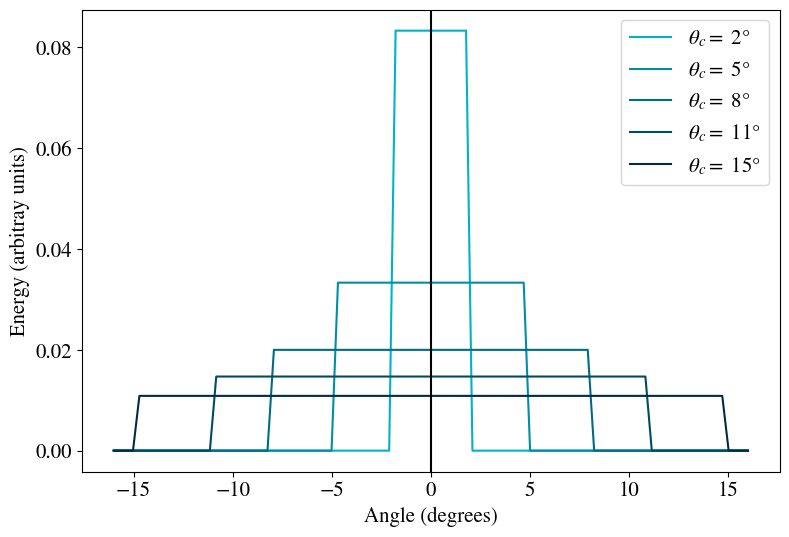

In [5]:
def energy_top_hat(theta, theta_c):
    ''' Uniform distribution
    '''
    energy = np.array([1]*len(theta))
    energy[np.abs(theta)>theta_c] = 0
    return energy


theta_c = [2, 5, 8, 11, 15]   # core angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 


for i, t in enumerate(theta_c):
    energy = energy_top_hat(theta, t)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = r'$\theta_c =$ %i°' %t)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

### Gaussian Jet

For a Gaussian jet : $E(\theta) = E_0\exp(-\frac{\theta^2}{2\theta_c^2})$ where $\theta_c$ is the width of the jet. For both Gaussian jet and Power-Law jet, a truncation angle $\theta_w$ is introduced, above which the energy is zero. 

#### Dependance in $\theta_c$

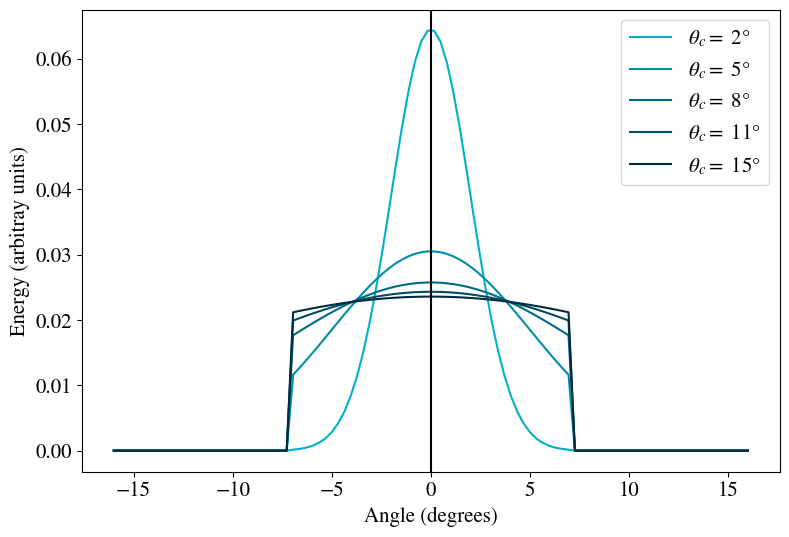

In [6]:
def energy_gaussian(theta, theta_c, theta_w):
    ''' Gaussian distribution
    '''
    energy = np.exp(-theta**2/(2*theta_c**2))
    energy[np.abs(theta)>theta_w] = 0.
    return energy


theta_w = 7 # truncature angle
theta_c = [2, 5, 8, 11, 15]   # core angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

for i, t in enumerate(theta_c):
    energy = energy_gaussian(theta, t, theta_w)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = r'$\theta_c =$ %i°' %t)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

#### Dependance in $\theta_w$

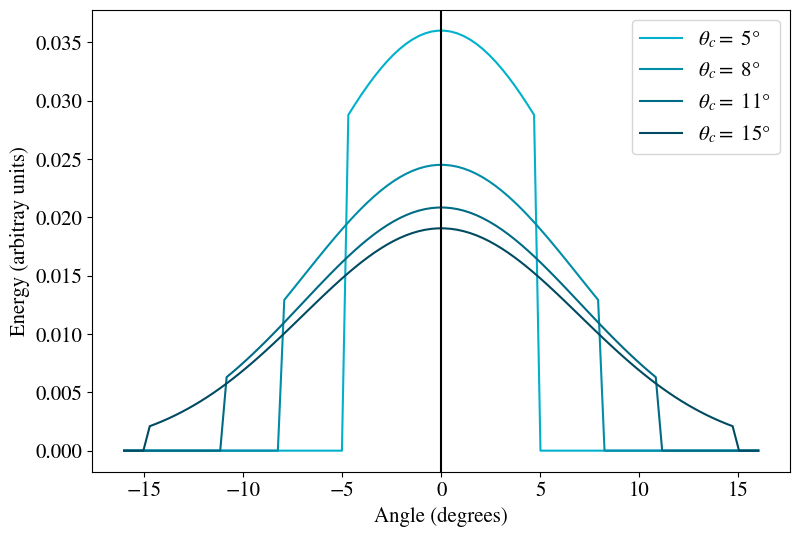

In [7]:
def energy_gaussian(theta, theta_c, theta_w):
    ''' Gaussian distribution
    '''
    energy = np.exp(-theta**2/(2*theta_c**2))
    energy[np.abs(theta)>theta_w] = 0.
    return energy


theta_w = [5, 8, 11, 15] # truncature angle
theta_c = 7   # core angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

for i, t in enumerate(theta_w):
    energy = energy_gaussian(theta, theta_c, t)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = r'$\theta_c =$ %i°' %t)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

### Power-Law Jet

For a Power-Law jet : $E(\theta) = E_0(1 + \frac{\theta^2}{b\theta_c^2})^{-b/2}$ where $b$ is the power law index. It serves to make it comparable between power laws of different $b$ and Gaussian jets. Its value is between 2 and 6 so the median value 4 is taken.

#### Dependance in $b$

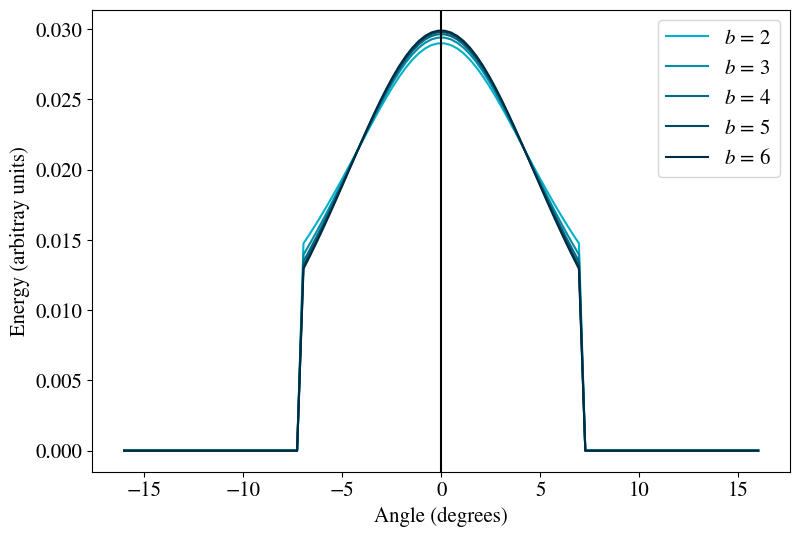

In [8]:
def energy_power_law(theta, theta_c, theta_w, b):
    ''' Power-Law distribution
    '''
    energy = (1 + theta**2/(b*theta_c**2))**(-b/2)
    energy[np.abs(theta)>theta_w] = 0.
    return energy

b = [2, 3, 4, 5, 6]
theta_w = 7 # truncature angle
theta_c = 5   # core angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

for i, a in enumerate(b):
    energy = energy_power_law(theta, theta_c, theta_w, a)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = '$b$ = %i' %a)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

#### Dependance in $\theta_c$

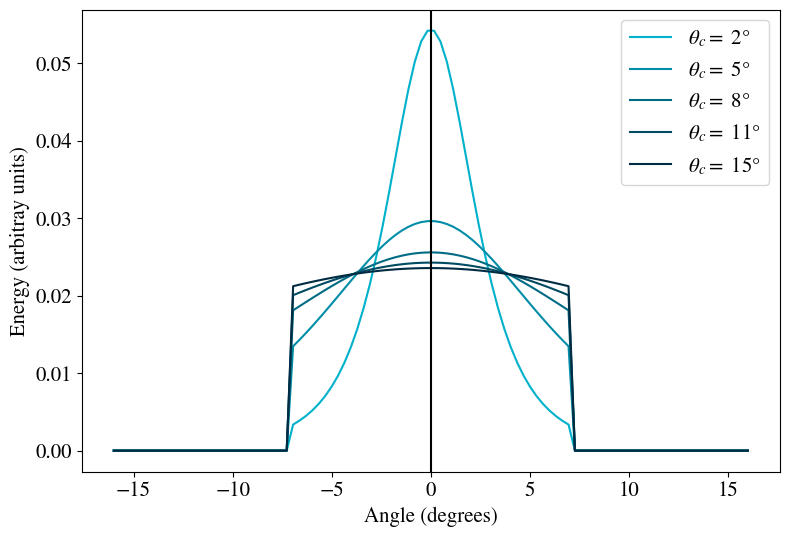

In [9]:
def energy_power_law(theta, theta_c, theta_w, b):
    ''' Power-Law distribution
    '''
    energy = (1 + theta**2/(b*theta_c**2))**(-b/2)
    energy[np.abs(theta)>theta_w] = 0.
    return energy

b = 4
theta_w = 7 # truncature angle
theta_c = [2, 5, 8, 11, 15]   # core angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

for i, t in enumerate(theta_c):
    energy = energy_power_law(theta, t, theta_w, b)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = r'$\theta_c =$ %i°' %t)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

#### Dependance in $\theta_w$

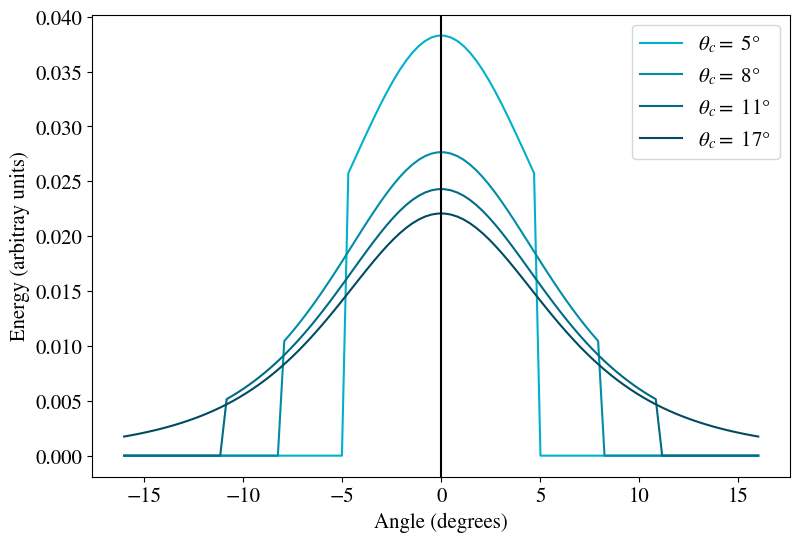

In [10]:
def energy_power_law(theta, theta_c, theta_w, b):
    ''' Power-Law distribution
    '''
    energy = (1 + theta**2/(b*theta_c**2))**(-b/2)
    energy[np.abs(theta)>theta_w] = 0.
    return energy

b = 4
theta_c = 5   # core angle
theta_w = [5, 8, 11, 17]   # truncature angle
theta = np.linspace(-16, 16, 100)   # viewing angle

colors = ['#00b1cb', '#008da7', '#006b84', '#004b62', '#002c43']

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

for i, t in enumerate(theta_w):
    energy = energy_power_law(theta, theta_c, t, b)
    energy_norm = [e/sum(energy) for e in energy]
    plt.plot(theta, energy_norm, color=colors[i], label = r'$\theta_c =$ %i°' %t)

plt.xlabel('Angle (degrees)')
plt.ylabel('Energy (arbitray units)')
plt.axvline(x=0, color='black', linestyle='-')
plt.legend()

### Visualisation of the different structures

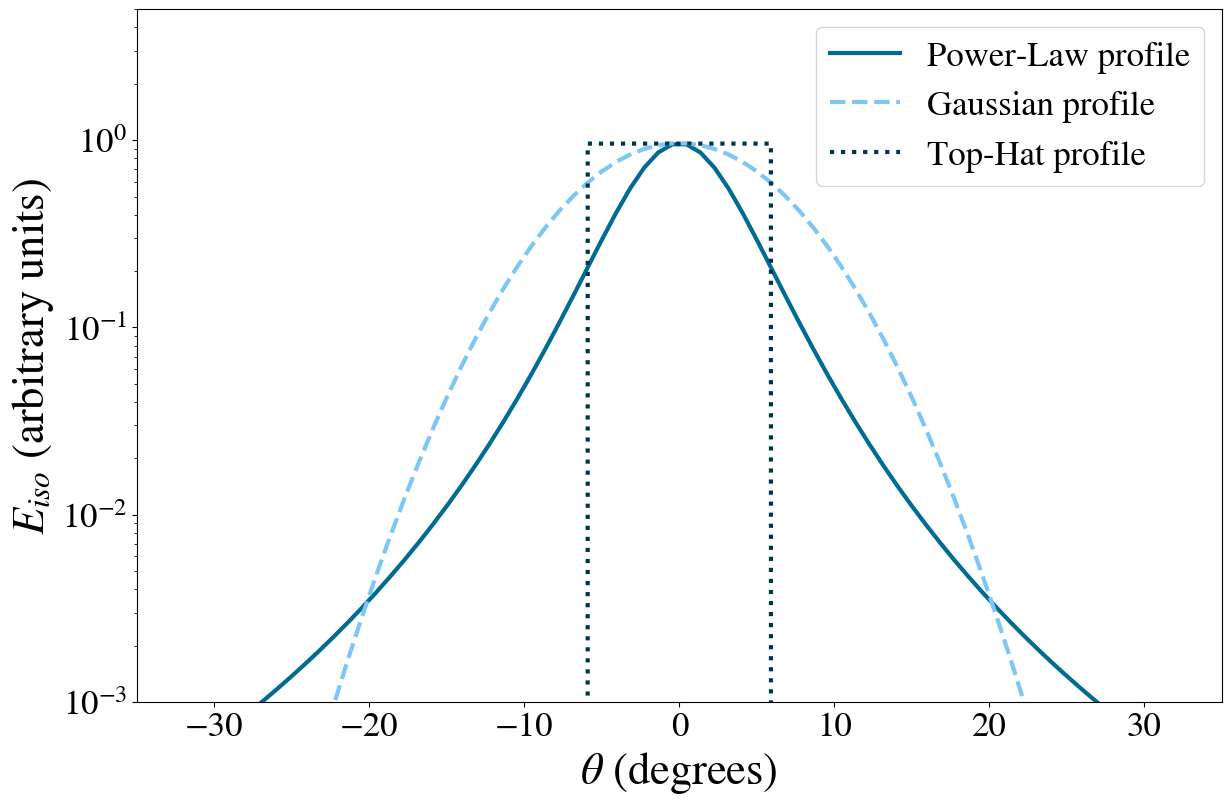

In [11]:
E0 = 10**52
theta_c = 6
theta_w = 90
b = 4.5

theta = np.linspace(-45, 45, 100)

def energy_not_norm_pl(theta, theta_c, b):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = (1 + theta**2/(theta_c**2))**(-b/2)
    return E

def energy_norm_pl(theta, theta_c, b, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0 * (1 + theta**2/(theta_c**2))**(-b/2)
    return E

def energy_not_norm_g(theta):
    if theta>90 or theta<-90:
        E = 0
    else:
        E = np.exp(-theta**2/(2*6**2))
    return E

def energy_norm_g(theta, E0):
    if theta>90 or theta<-90:
        E = 0
    else:
        E = E0 * np.exp(-theta**2/(2*6**2))
    return E

def energy_not_norm_th(theta):
    if theta>6 or theta<-6:
        E = 0
    else:
        E = 1
    return E

def energy_norm_th(theta, E0):
    if theta>6 or theta<-6:
        E = 0
    else:
        E = E0
    return E

plt.rcParams.update({'font.size': 25})
fig, ax = plt.subplots(1, 1, figsize=(14,9))

E_pl = []
integral_E_pl, err_pl = quad(energy_not_norm_pl, -np.inf, np.inf, args=(theta_c, b))
E0_norm_pl = 8.3/integral_E_pl

E_g = []
integral_E_g, err_g = quad(energy_not_norm_g, -np.inf, np.inf)
E0_norm_g = 14.5/integral_E_g

E_th = []
integral_E_th, err_th = quad(energy_not_norm_th, -np.inf, np.inf)
E0_norm_th = 11.5/integral_E_th

for i in theta:
    E_pl.append(energy_norm_pl(i, theta_c, b, E0_norm_pl))
    E_g.append(energy_norm_g(i, E0_norm_g))
    E_th.append(energy_norm_th(i, E0_norm_th))

#['#007c95', '#00b1cb', '#00344b']

plt.xlim(-35, 35.)
plt.ylim(0.001, 5.)
plt.xlabel(r'$\theta$ (degrees)', fontsize=32)
plt.ylabel('$E_{iso}$ (arbitrary units)', fontsize=32)
plt.plot(theta, E_pl, color='#006b93', lw=3, label='Power-Law profile')
plt.plot(theta, E_g, color='#7ec6f3', lw=3, ls='--', label='Gaussian profile')
plt.plot(theta, E_th, color='#00344b', lw=3, ls=':', label='Top-Hat profile')
plt.yscale('log')
plt.legend()

#plt.savefig('../figures/jet_angular_structure.pdf', format="pdf", bbox_inches="tight", transparent=True)
#plt.savefig('../figures/jet_angular_structure.png', transparent=True)

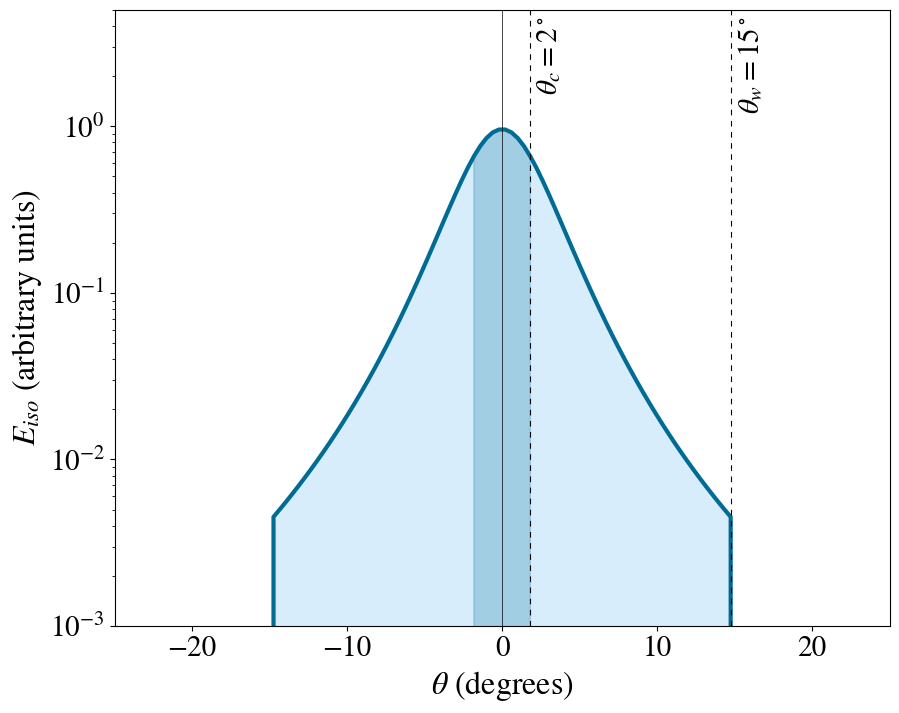

In [12]:
E0 = 10**52
theta_c = 2
theta_w = 15
b = 4

theta = np.linspace(-20, 20, 100)

def energy_not_norm_pl(theta, theta_c, b):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E

def energy_norm_pl(theta, theta_c, b, E0):
    if theta>theta_w or theta<-theta_w:
        E = 0
    else:
        E = E0 * (1 + theta**2/(b*theta_c**2))**(-b/2)
    return E

def energy_not_norm_g(theta):
    if theta>12 or theta<-12:
        E = 0
    else:
        E = np.exp(-theta**2/(2*6**2))
    return E

def energy_norm_g(theta, E0):
    if theta>12 or theta<-12:
        E = 0
    else:
        E = E0 * np.exp(-theta**2/(2*6**2))
    return E

plt.rcParams.update({'font.size': 21})
fig, ax = plt.subplots(1, 1, figsize=(10,8))

E_pl = []
integral_E_pl, err_pl = quad(energy_not_norm_pl, -np.inf, np.inf, args=(theta_c, b))
E0_norm_pl = 6/integral_E_pl

E_g = []
integral_E_g, err_g = quad(energy_not_norm_g, -np.inf, np.inf)
E0_norm_g = 14/integral_E_g

for i in theta:
    E_pl.append(energy_norm_pl(i, theta_c, b, E0_norm_pl))
    E_g.append(energy_norm_g(i, E0_norm_g))

plt.xlim(-25, 25.)
plt.ylim(0.001, 5.)
plt.xlabel(r'$\theta$ (degrees)', fontsize=23)
plt.ylabel('$E_{iso}$ (arbitrary units)', fontsize=23)
plt.plot(theta, E_pl, color='#006b93', lw=3)
#plt.plot(theta, E_g, color='#7ec6f3', lw=3, ls='--', label='Gaussian profile')
plt.fill_between(theta, E_pl, color = '#006b93', alpha=0.3, where = (theta > -2) & (theta < 2), label='Core')
plt.fill_between(theta, E_pl, color = '#7ec6f3', alpha=0.3, where = (theta > -14.8) & (theta < 14.8), label='Wings')
#plt.axvline(x=-14.8, ls=(0, (5, 5)), color='k', lw=0.8)
plt.axvline(x=0, color='k', lw=0.5)
plt.axvline(x=14.79, ls=(0, (5, 5)), color='k', lw=0.8)
#plt.axvline(x=-1.9, ls=(0, (5, 5)), color='k', lw=0.8)
plt.axvline(x=1.81, ls=(0, (5, 5)), color='k', lw=0.8)
plt.text(2.2, 1.7, r'$\theta_c = 2^\circ$', rotation='vertical')
plt.text(15.2, 1.3, r'$\theta_w = 15^\circ$', rotation='vertical')

plt.yscale('log')
#plt.legend(loc='upper right')

#plt.savefig('../figures/energy_structure.pdf', format="pdf", bbox_inches="tight", transparent=True)

## Light curves and spectra

The `afterglowpy` package is calibrated thanks to the `BoxFit` code (https://arxiv.org/abs/1006.5125).
This package utilizes a trans-relativistic equation of state and the single shell approximation to solve the shock evolution equations :

$$ \left\{   \begin{array}{rcl}
& \dot R = \frac{4u\gamma}{4u^2+3}c \\
& \dot \theta_j = \frac{1}{2\gamma}\sqrt{\frac{2u^2+3}{4u^2+3}}\frac{\dot R}{R} \\
& \dot u = -\frac{E_{sw}(4u^2+3)\beta^2(3\dot R/R + cot(\theta_j/2)\dot \theta_j) - \partial_tE}{2E_{sw}u(4u^4 + 8u^2 + 3)\gamma^{-4} + \beta M_{ej}c^2 - \partial_uE}
\end{array}
\right. $$

Where $R$ is the radial position of the blast wave, $\theta_j$ is the opening angle of the jet, $u$ is the dimensionless four-velocity of the fluid behind the shock, $M_{ej}$ is the ejected mass and finally, $E_{sw} = \frac{4\pi}{9}\rho_0c^2R^3f_\Omega$ with $f_\Omega = 2\sin^2(\theta_j/2)$ and $\rho_0 = m_pn_0$ the rest-mass density of the cold ambient medium.


### Multiband Light Curve

Photometric filters used by LSST :
- u = 320.5–393.5 nm,
- g = 401.5–551.9 nm,
- r = 552.0–691.0 nm,
- i = 691.0–818.0 nm,
- z = 818.0–923.5 nm, 
- y = 923.8–1084.5 nm.

For each filters, the wavelength range's mean is taken for plotting the light curves.

Core's angle is 5.73°.
Wing's angle is 8.59°.
Observer's angle is 11.46°.
The color g-r is 0.28 ± 0.07.


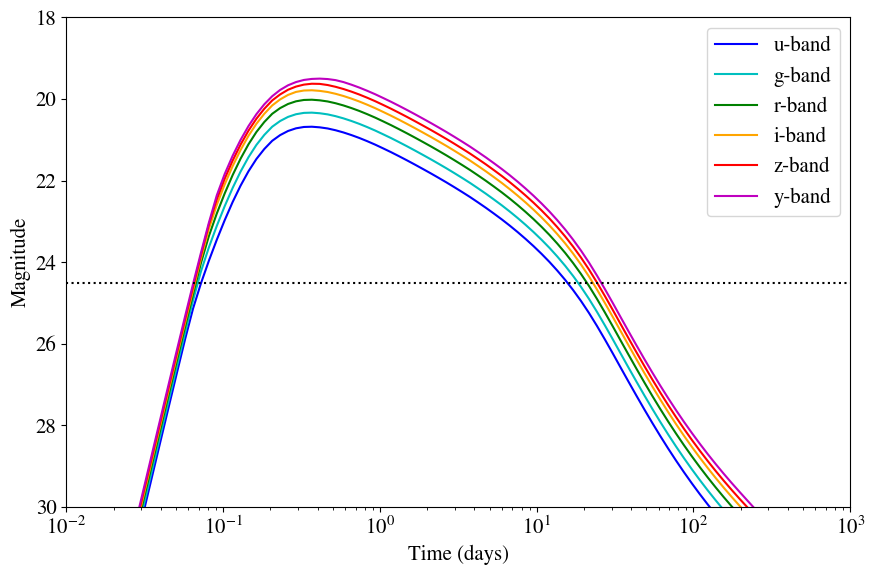

In [13]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,    # Power Law index
     'thetaObs':    0.2,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.15,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(1, 1, figsize=(9,6)) 

# Time and Frequencies
ta = 1.0e-2 * grb.day2sec
tb = 1.0e3 * grb.day2sec
t = np.geomspace(ta, tb, num=100)

# Mean wavelengths (in nm) and frequencies of each photometric filter
l_filters = [357., 476.7, 621.5, 754.5, 870.75, 1004.15]   # LSST filters u, g, r, i, z, y
nu_filters = [3e8/(l_filters[i]*1.0e-9) for i in range(len(l_filters))]

colors = ['b', 'c', 'g', 'orange', 'r', 'm']
labels = ['u-band', 'g-band', 'r-band', 'i-band', 'z-band', 'y-band']


# Calculate the magnitudes 
for i in range(len(l_filters)):
    mag = -2.5 * np.log10(grb.fluxDensity(t, nu_filters[i], **Z)*1.0e-26) - 48.6
    if i == 1:
        mag_g = mag
    if i == 2:
        mag_r = mag
    ax.plot(t*grb.sec2day, mag, label=labels[i], color=colors[i])

dmag = mag_g - mag_r

ax.set_xscale('log')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Magnitude')
ax.legend()
plt.gca().invert_yaxis()
plt.axhline(y=24.5, color='black', linestyle=':', label='Rubin/LSST limiting magnitude')
plt.xlim(0.01,1000)
plt.ylim(30,18)

print("Core's angle is %.2f°." %(math.degrees(Z['thetaCore'])))
if Z['jetType'] == grb.jet.Gaussian or Z['jetType'] == grb.jet.PowerLaw:
    print("Wing's angle is %.2f°." %(math.degrees(Z['thetaWing'])))
print("Observer's angle is %.2f°." %(math.degrees(Z['thetaObs'])))

print('The color g-r is %.2f ± %.2f.' %(np.mean(dmag), np.std(dmag)))

fig.tight_layout()

### Variation of the parameters

#### Comparison of the jet types

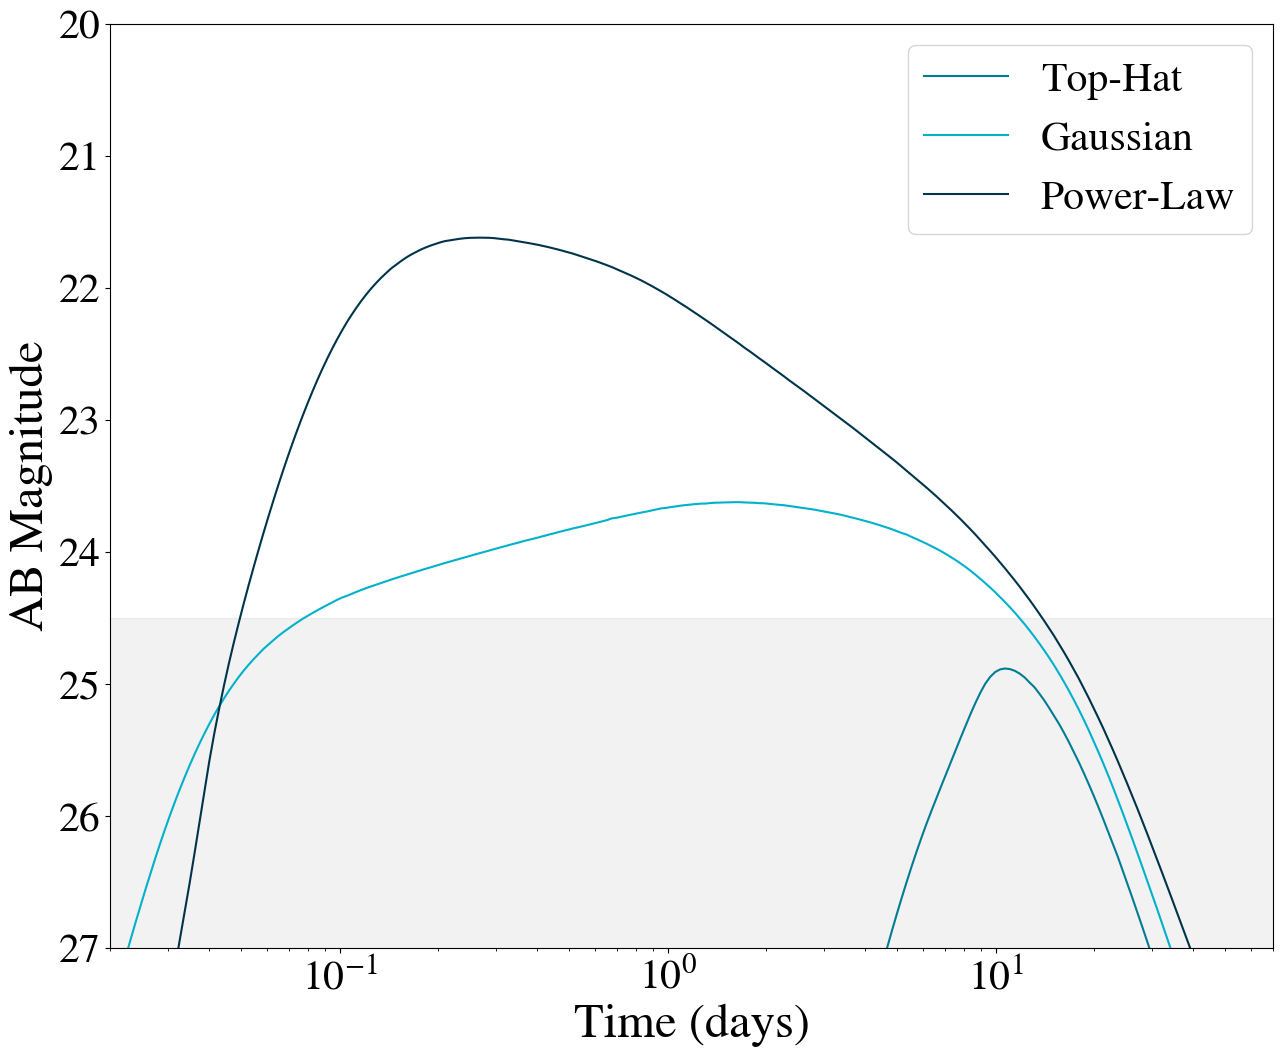

In [14]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.25,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle in radians
     'thetaCore':   0.06,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.0e28,  # Luminosity distance in cm
     'z':           0.55}    # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 3.0e7, 300)

# Calculate flux in optical (r-band : wavelength = 600 nm)
# The frequency is the same at each time
nu = np.empty(t.shape)
nu[:] = 5.0e14   

# Top-Hat: -1, Gaussian: 0, Power-Law: 4)
jettype = [-1, 0, 4]
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']
colors = ['#007c95', '#00b1cb', '#00344b']


plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(15,12))

# Calculate the flux in Jansky and the AB Magnitude for each jet type and plot the magnitude
for i, j in enumerate(jettype):
    Z['jetType'] = j
    Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3
    mag = -2.5 * np.log10(Fnu*1.0e-23) - 48.6
    plt.plot(t*grb.sec2day, mag, color=colors[i], label = jettype_name[i])


plt.xlabel('Time (days)', fontsize=35)
plt.ylabel('AB Magnitude', fontsize=35)
plt.gca().invert_yaxis()
plt.xscale('log')
#plt.axhline(y=24.5, color='black', linewidth=0.5, label='Rubin LSST nightly limiting magnitude')
plt.fill_between([1e-2, 1e3], 24.5, 31., color='k', alpha=0.05)
plt.xlim(0.02, 70)
plt.ylim(27, 20)

plt.legend()

#ax2 = ax1.twinx()

#ax2.plot(t*grb.sec2day, FnuPL*1000, color='royalblue', linestyle='-', label = 'Power Law')
#ax2.set_ylabel('Flux (Jy)', fontsize=23)
#ax2.set_yscale('log')
#ax2.set_ylim(mag_to_flux(30), mag_to_flux(5))

#fig.tight_layout()

#plt.show()

#plt.savefig('../figures/orphan_lc_th.png', bbox_inches="tight", transparent=True)
#plt.savefig('../figures/orphan_lc_th.pdf', format="pdf", bbox_inches="tight", transparent=True)

#### Angle of the observer $\theta_{obs}$

$\theta_c$ and $\theta_w$ remain unchanged in this part.

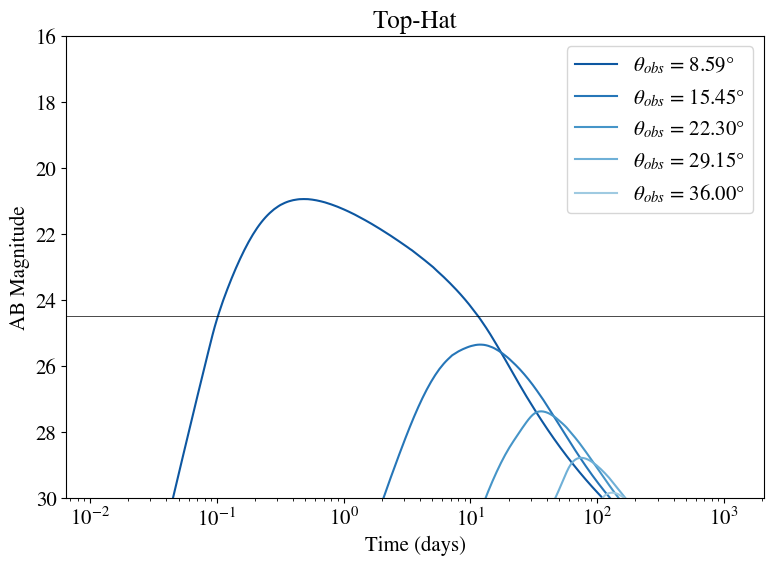

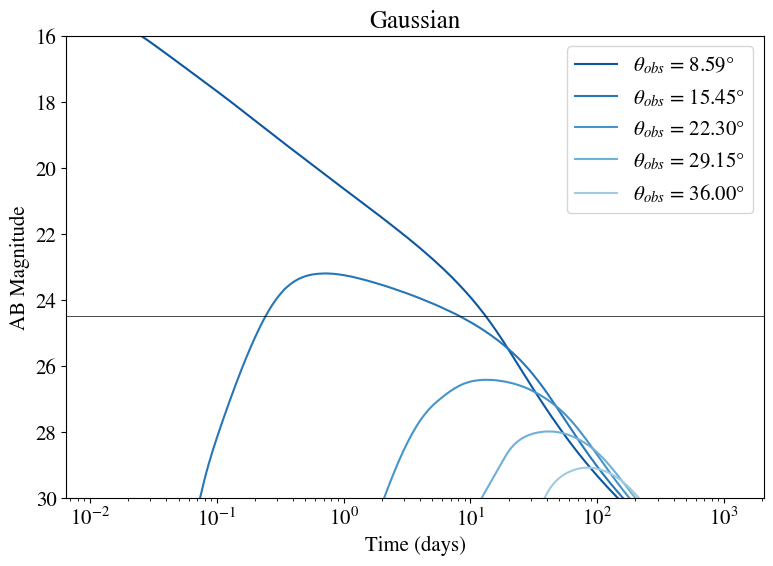

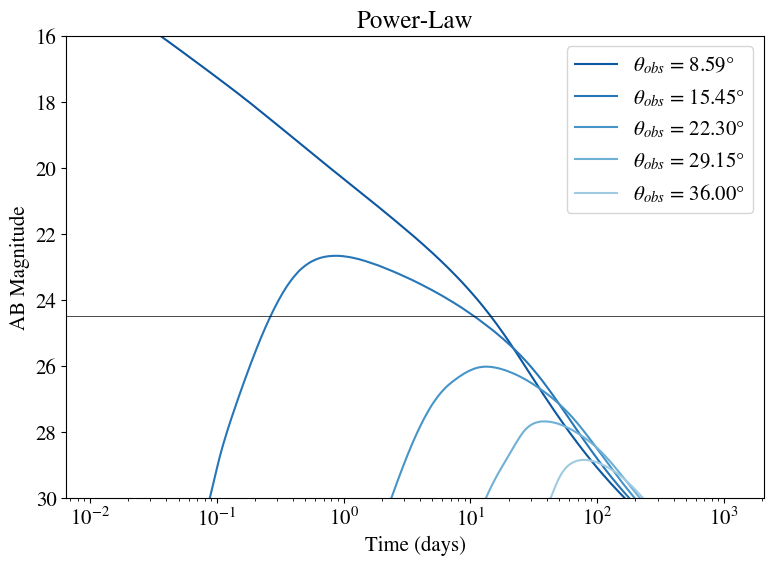

In [15]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    1,                  # Basic Synchrotron Emission Spectrum
     'b':           2,      # Power Law index
     'thetaObs':    0.31,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle
     'thetaCore':   0.1,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift


t = np.geomspace(1.0e3, 1.0e8, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14


thetaObs = np.linspace(0.15, np.pi/5, 5)
jettype = [-1, 0, 4]
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']
   
    
for jet, name in zip(jettype, jettype_name):
    
    Z['jetType'] = jet
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(1, 1, figsize=(9,6)) 
    
    for theta in thetaObs:
        Z['thetaObs'] = theta
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_{obs}$ = %.2f°' %(math.degrees(theta)), 
                 color=cm.Blues(1-theta))
    
    
    plt.title('%s' %name)
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    plt.ylim(30,16)
    plt.axhline(y=24.5, color='black', linewidth='0.5')
    plt.legend()
    
    plt.show()

#### Angle of the core $\theta_c$ for 2 different values of $\theta_w$

$\theta_{obs}$ remains unchanged in this part.

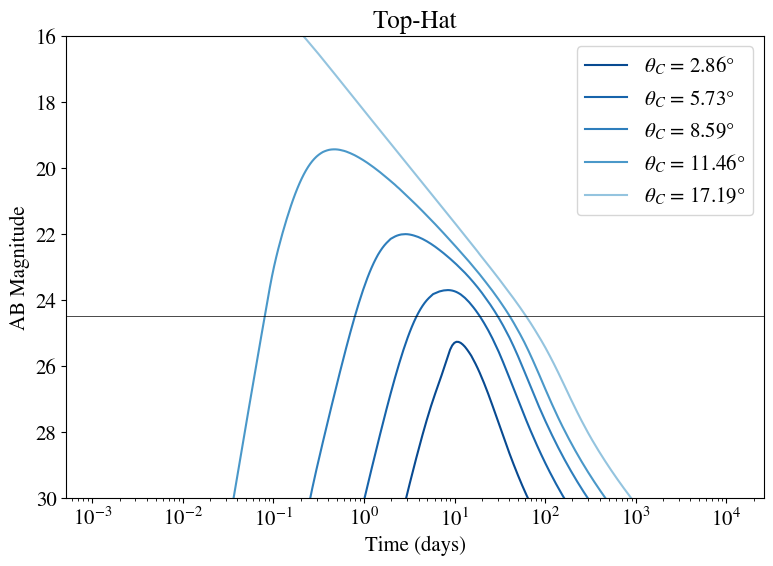

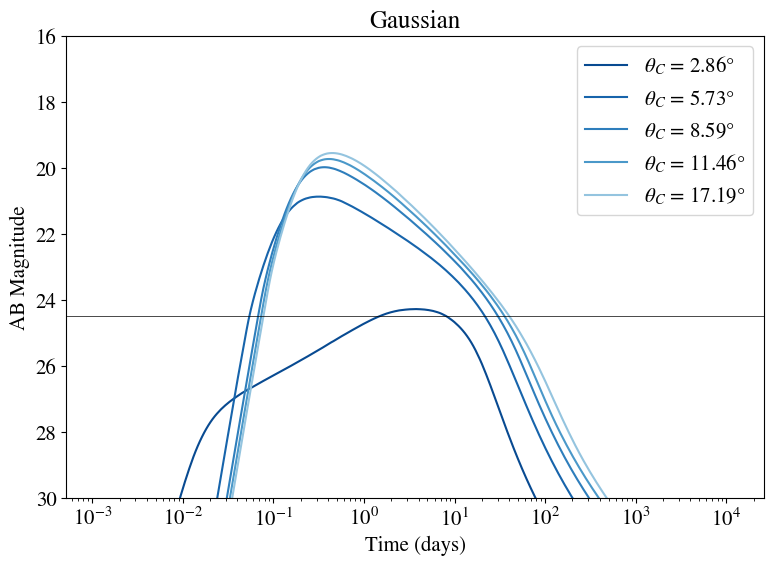

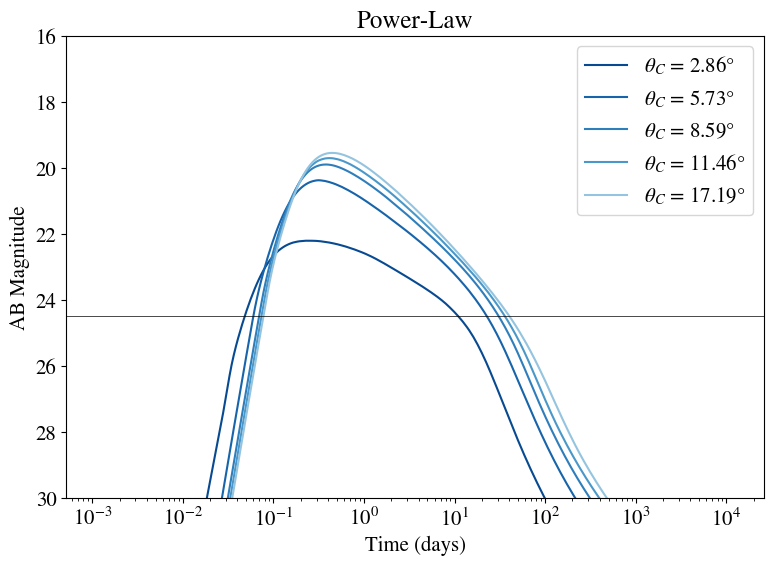

In [16]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.25,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

t = np.geomspace(1.0e2, 1.0e9, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14

thetaCore = [0.05, 0.1, 0.15, 0.2, 0.3]
jettype = [-1, 0, 4]
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']


for jet, name in zip(jettype, jettype_name):
    
    Z['jetType'] = jet
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(1, 1, figsize=(9,6))
    
    for theta in thetaCore:
        Z['thetaCore'] = theta
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_C$ = %.2f°' %(math.degrees(theta)), 
                 color=cm.Blues(1-2*theta))

    plt.title('%s' %name)
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    plt.ylim(30,16)
    plt.axhline(y=24.5, color='black', linewidth=0.5)
    plt.legend()
    
    plt.show()

#### Angle of the wings $\theta_w$

$\theta_c$ remains unchanged in this part.

##### $\theta_w$ for a single value of $\theta_{obs}$

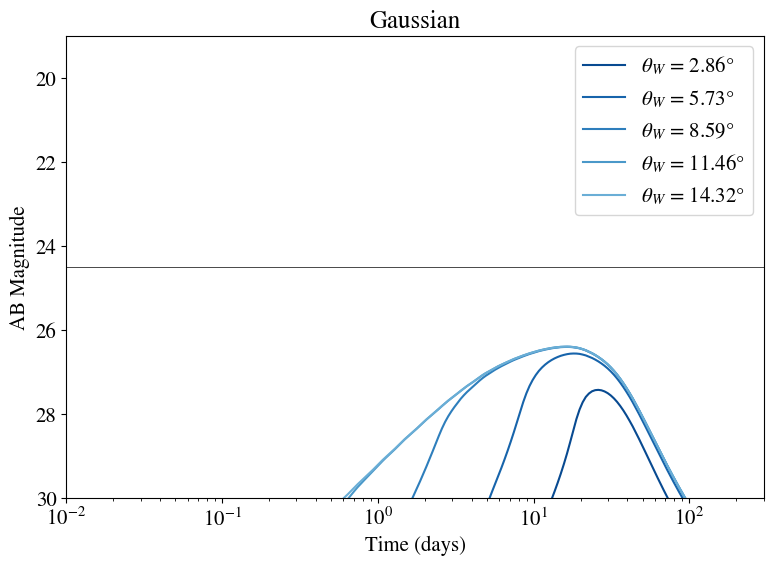

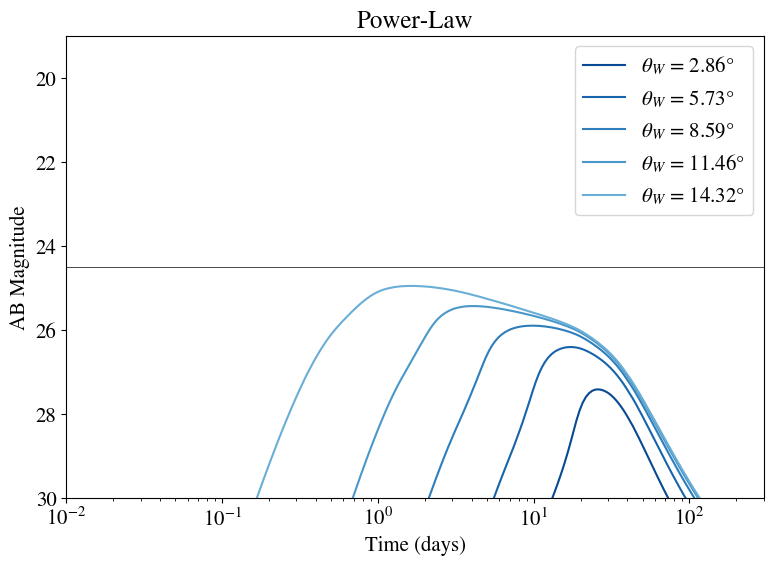

In [17]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.36,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.25,   # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift


t = np.geomspace(1.0e3, 1.0e9, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14

thetaWing = [0.05, 0.1, 0.15, 0.2, 0.25] # Truncature angle
jettype = [0, 4]
jettype_name = ['Gaussian', 'Power-Law']


for jet, name in zip(jettype, jettype_name):
    
    Z['jetType'] = jet
    
    plt.rcParams.update({'font.size': 15})
    fig, ax = plt.subplots(1, 1, figsize=(9,6))

    for theta in thetaWing:
        Z['thetaWing'] = theta
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6
        plt.plot(t*grb.sec2day, mag, label = r'$\theta_W$ = %.2f°' %(math.degrees(theta)), 
                 color=cm.Blues(1-2*theta))
    
    plt.title('%s' %name)
    plt.xlabel('Time (days)')
    plt.ylabel('AB Magnitude')
    plt.gca().invert_yaxis()
    plt.xscale('log')
    #plt.yscale('log')
    plt.xlim(0.01,300)
    plt.ylim(30,19)
    plt.axhline(y=24.5, color='black', linewidth=0.5)
    plt.legend()
    
    plt.show()

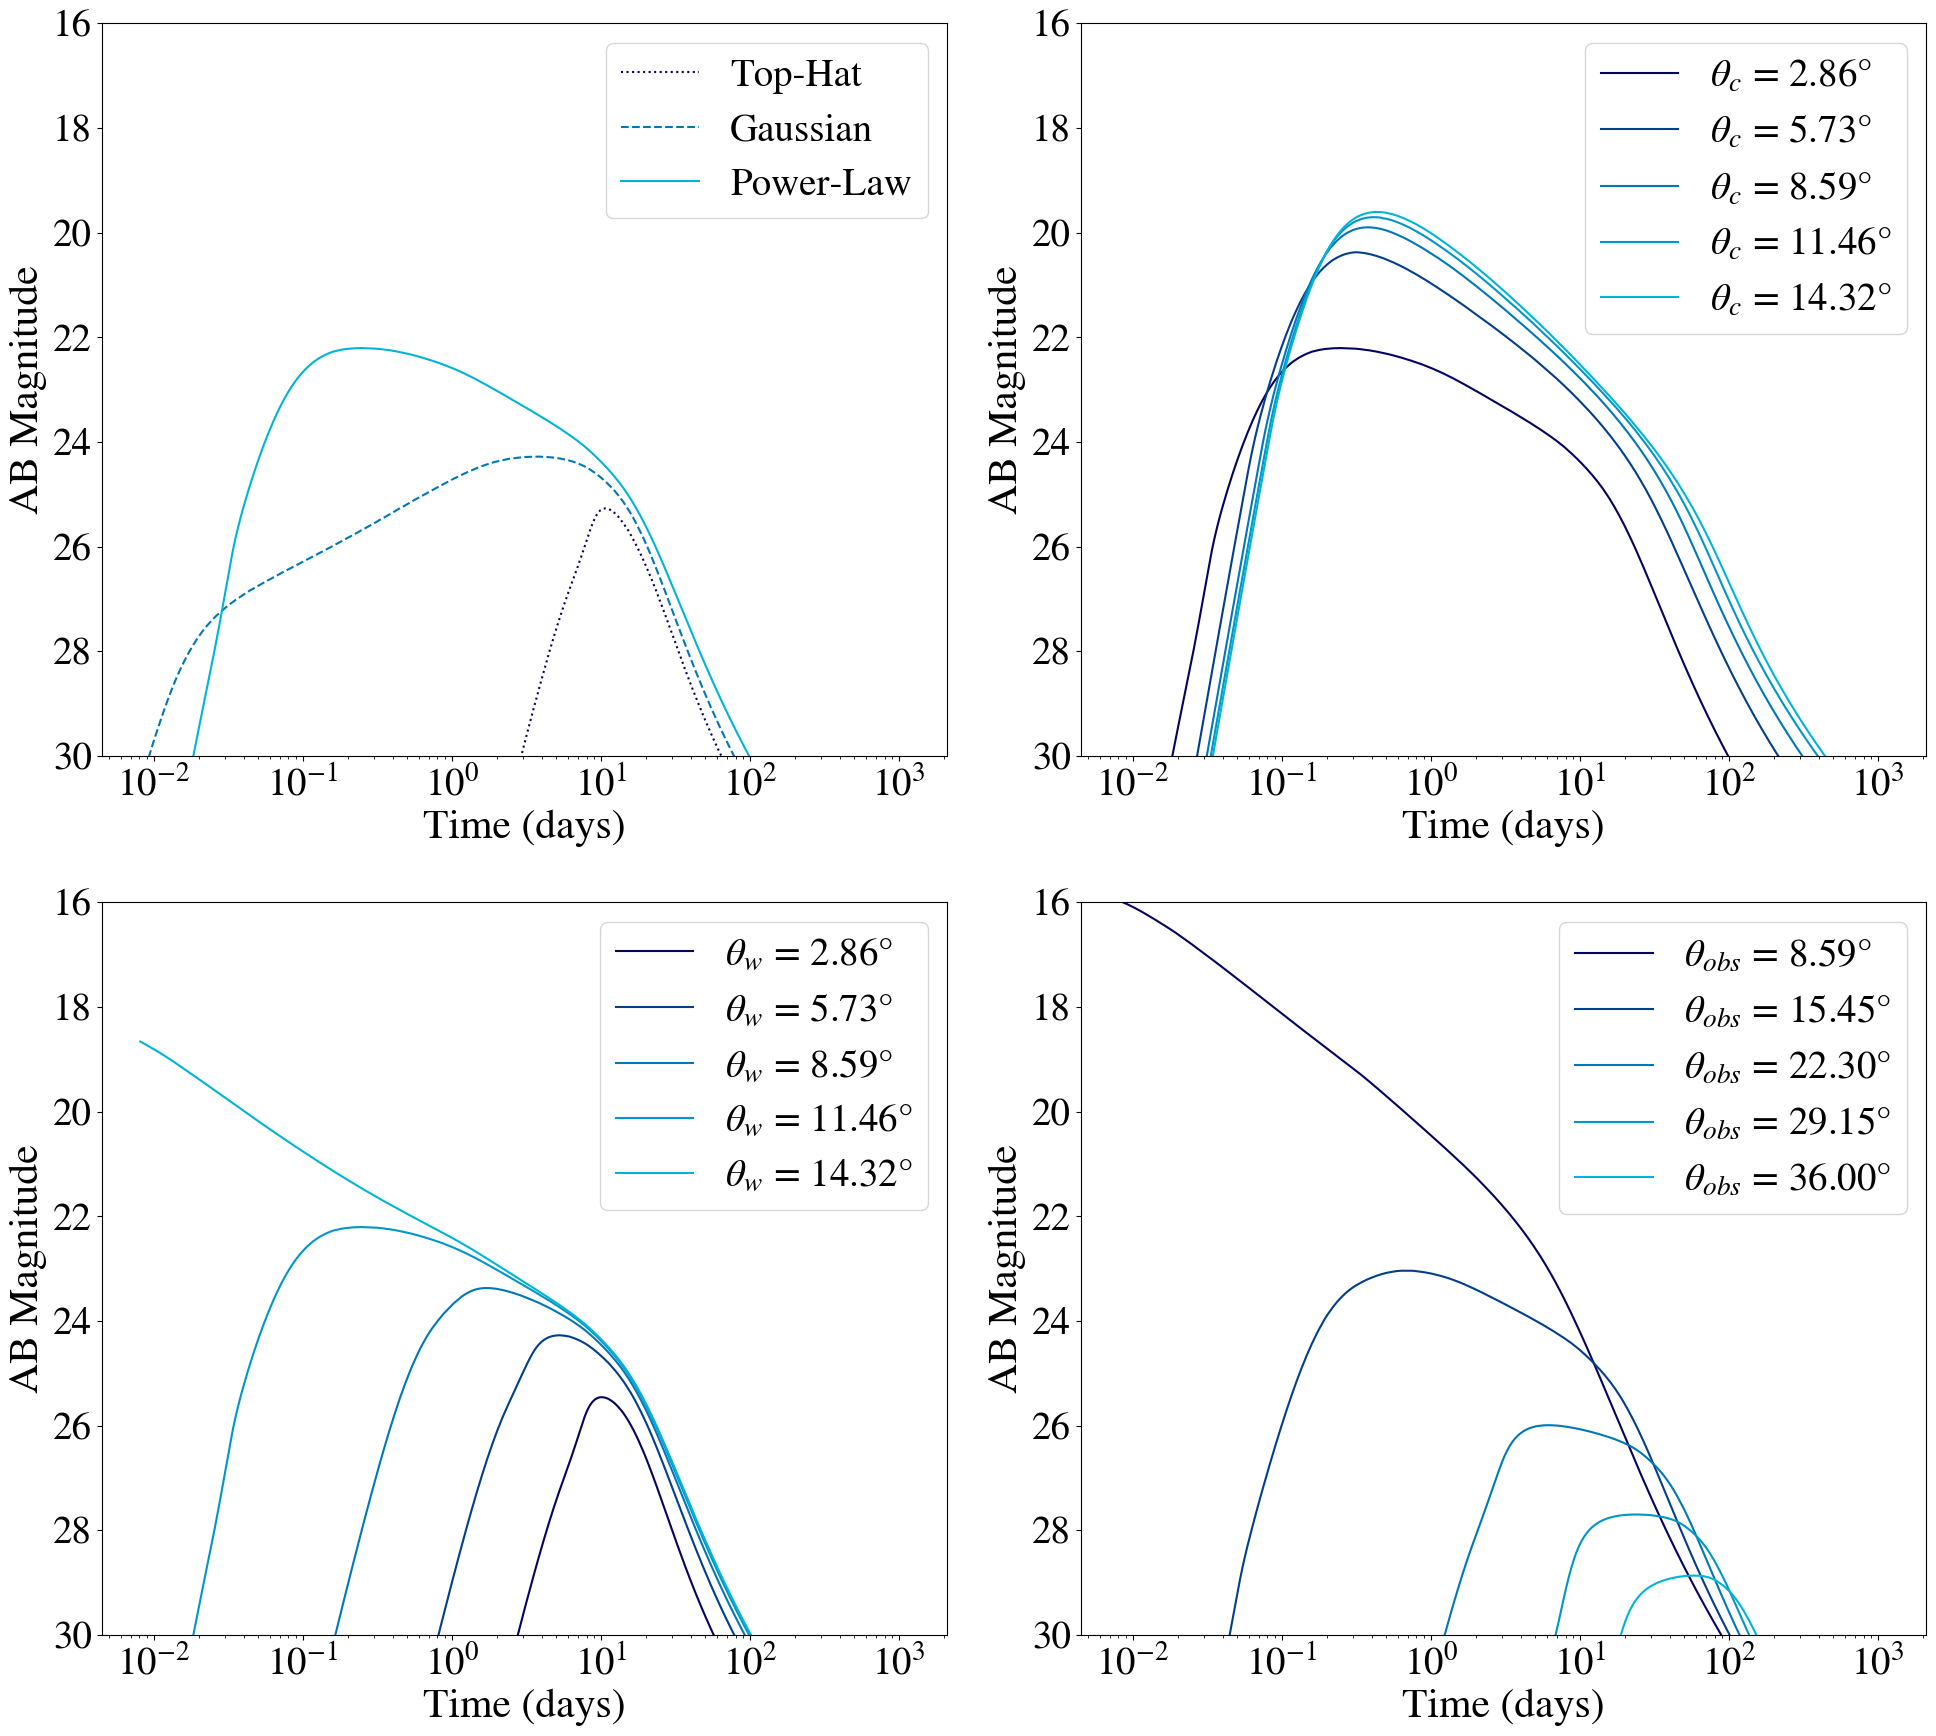

In [18]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.25,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

t = np.geomspace(7.0e2, 1.0e8, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14

jettype_list = [-1, 0, 4]   # Jet type
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']
thetaCore_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25])   # Core angle
thetaWing_list = np.array([0.05, 0.1, 0.15, 0.2, 0.25])   # Truncature angle
thetaObs_list = np.linspace(0.15, np.pi/5, 5)   # Observer angle

params = [jettype_list, thetaCore_list, thetaWing_list, thetaObs_list]
params_name = ['jetType', 'thetaCore', 'thetaWing', 'thetaObs']
angles_label = [r'$\theta_c$', r'$\theta_w$', r'$\theta_{obs}$']

colors = ['#03045e', '#023e8a', '#0077b6', '#0096c7', '#00b4d8', '#48cae4', '#90e0ef']
colors_jet = ['#03045e', '#0077b6', '#00b4d8']
styles = [':', '--', '-']

plt.rcParams.update({'font.size': 28})
fig, axes = plt.subplots(figsize=(20,18), nrows=2, ncols=2)

for i in range(4):
    
    ax = axes[i//2, i%2]
    #ax.legend()
    
    for p in params[i]:
        Z['jetType'] = 4
        Z['thetaCore'] = 0.05
        Z['thetaWing'] = 0.2
        Z['thetaObs'] = 0.25
        Z[params_name[i]] = p
        
        mag = -2.5 * np.log10(grb.fluxDensity(t, nu, **Z)*1.0e-26) - 48.6

        if i > 0:
            ax.plot(t*grb.sec2day, mag, label = f'{angles_label[i-1]} = %.2f°' %(math.degrees(p)), 
                     color=colors[np.where(params[i] == p)[0][0]])
        else:
            ax.plot(t*grb.sec2day, mag, label = jettype_name[jettype_list.index(p)], 
                     color=colors_jet[jettype_list.index(p)], ls=styles[jettype_list.index(p)])

    ax.legend()
    ax.set_ylabel('AB Magnitude', fontsize=30)
    ax.set_xlabel('Time (days)', fontsize=30)
    ax.invert_yaxis()
    ax.set_xscale('log')
    ax.set_ylim(30, 16)
    
plt.tight_layout() 

#plt.savefig('../figures/angles_study.pdf', format="pdf", bbox_inches="tight", transparent=True)

#### Other parameters

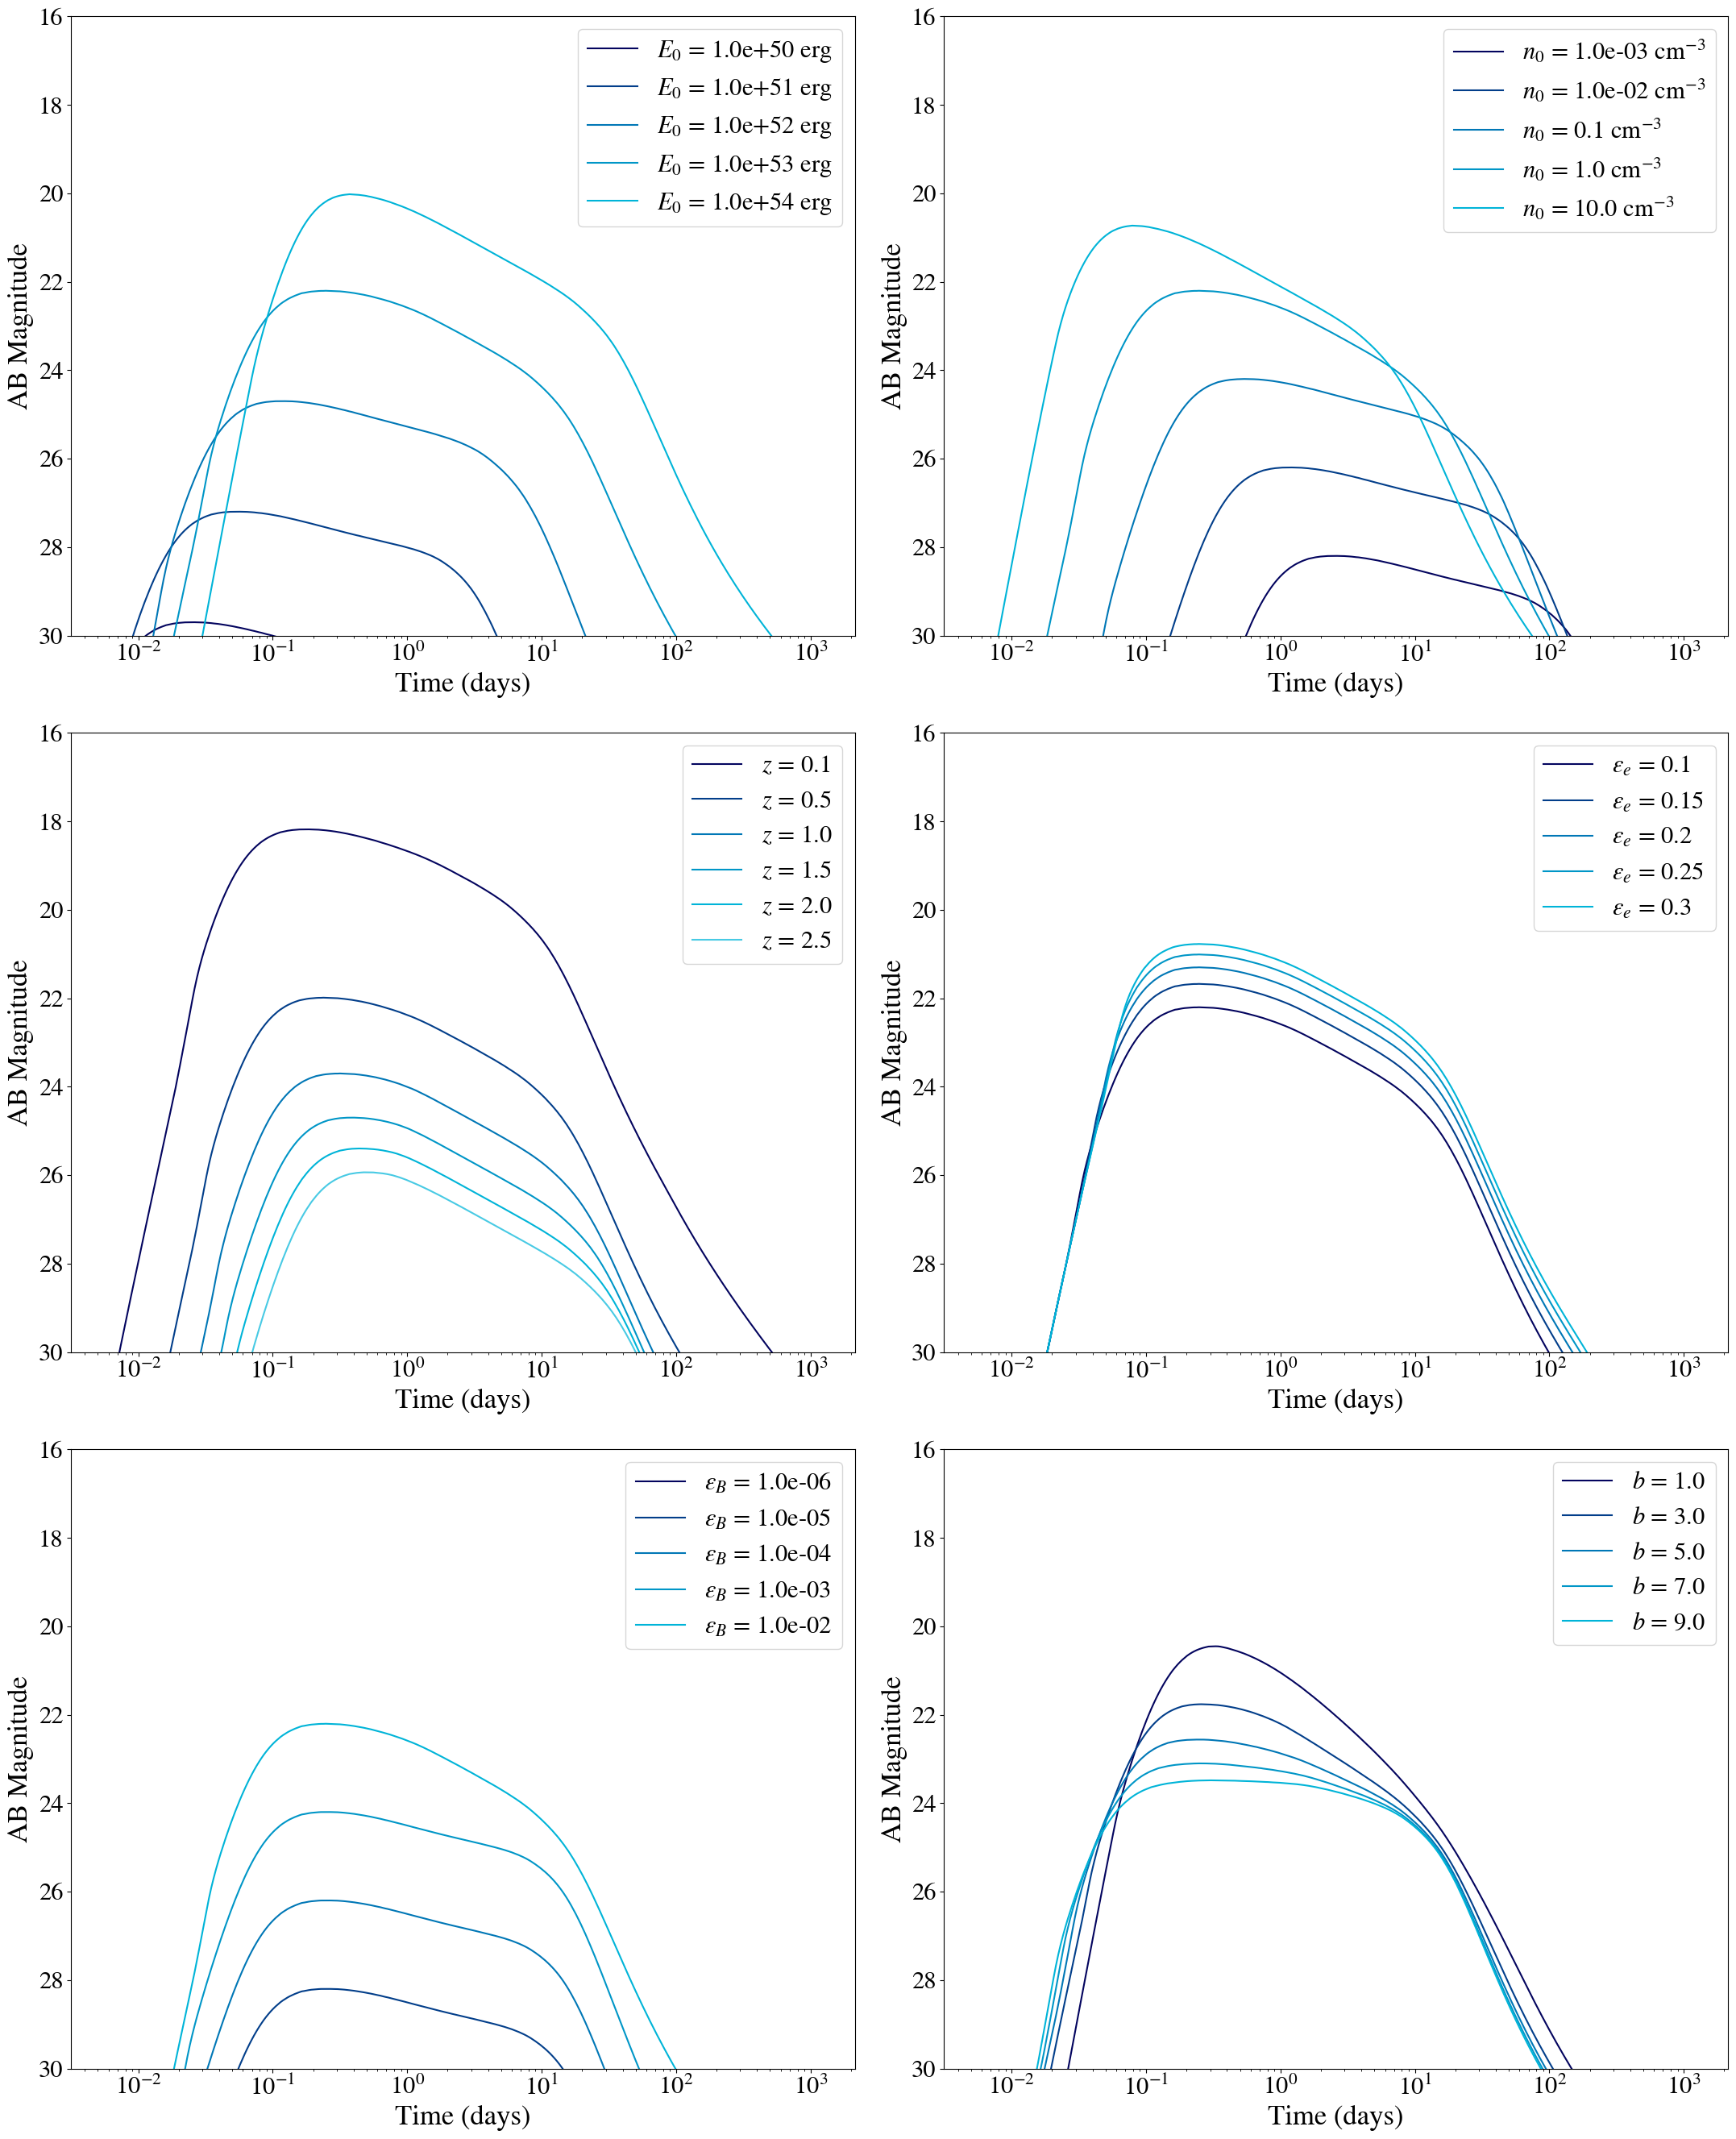

In [19]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Basic Synchrotron Emission Spectrum
     'b':           4,      # Power Law index
     'thetaObs':    0.25,   # Viewing angle
     'E0':          1.0e53, # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle
     'thetaCore':   0.05,   # Half-opening angle in radians
     'n0':          1.0,    # Circumburst density in cm^{-3}
     'p':           2.2,    # Electron energy distribution index
     'epsilon_e':   0.1,    # epsilon_e
     'epsilon_B':   0.01,   # epsilon_B
     'xi_N':        1.0,    # Fraction of electrons accelerated
     'd_L':         1.0e28, # Luminosity distance in cm
     'z':           0.55}   # Redshift

t = np.geomspace(5.0e2, 1.0e8, 300)
nu = 5.0e14

params_name = ['E0', 'n0', 'z', 'epsilon_e', 'epsilon_B', 'b']
params_label = [r'$E_0$', r'$n_0$', r'$z$', r'$\epsilon_e$', r'$\epsilon_B$', r'$b$']
params_units = ['erg', r'cm$^{-3}$', '', '', '', '']

params_values = [
    [1e50, 1e51, 1e52, 1e53, 1e54],       # E0
    [0.001, 0.01, 0.1, 1.0, 10.0],        # n0
    [0.1, 0.5, 1.0, 1.5, 2.0, 2.5],       # z
    [0.1, 0.15, 0.2, 0.25, 0.3],          # epsilon_e
    [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],       # epsilon_B
    [1.0, 3.0, 5.0, 7.0, 9.0]             # b
]

colors_param = ['#03045e', '#023e8a', '#0077b6', '#0096c7', '#00b4d8', '#48cae4']

plt.rcParams.update({'font.size': 22})
fig, axes = plt.subplots(figsize=(22, 27), nrows=3, ncols=2)

for i in range(6):
    ax = axes[i//2, i%2]

    for j, p in enumerate(params_values[i]):
        Z.update({'E0': 1e53, 'n0': 1.0, 'z': 0.55, 'd_L': 1.0e28, 'epsilon_e': 0.1, 'epsilon_B': 0.01, 'b': 4})
        Z[params_name[i]] = p

        if params_name[i] == 'z':
            Z['d_L'] = cosmo.luminosity_distance(p).value * 3.08e24

        flux = grb.fluxDensity(t, nu, **Z)
        mag = -2.5 * np.log10(flux * 1.0e-26) - 48.6

        if isinstance(p, float) and (p < 0.1 or p > 10):
            label = rf"{params_label[i]} = {p:.1e} {params_units[i]}"
        else:
            label = rf"{params_label[i]} = {p} {params_units[i]}"

        ax.plot(t*grb.sec2day, mag,
                label=label,
                color=colors_param[j % len(colors_param)])

    ax.set_ylabel("AB Magnitude", fontsize=25)
    ax.set_xlabel("Time (days)", fontsize=25)
    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.set_ylim(30, 16)
    ax.legend(fontsize=22)

plt.tight_layout()
#plt.savefig("../figures/study_all_parameters.pdf", format="pdf", bbox_inches="tight", transparent=True)

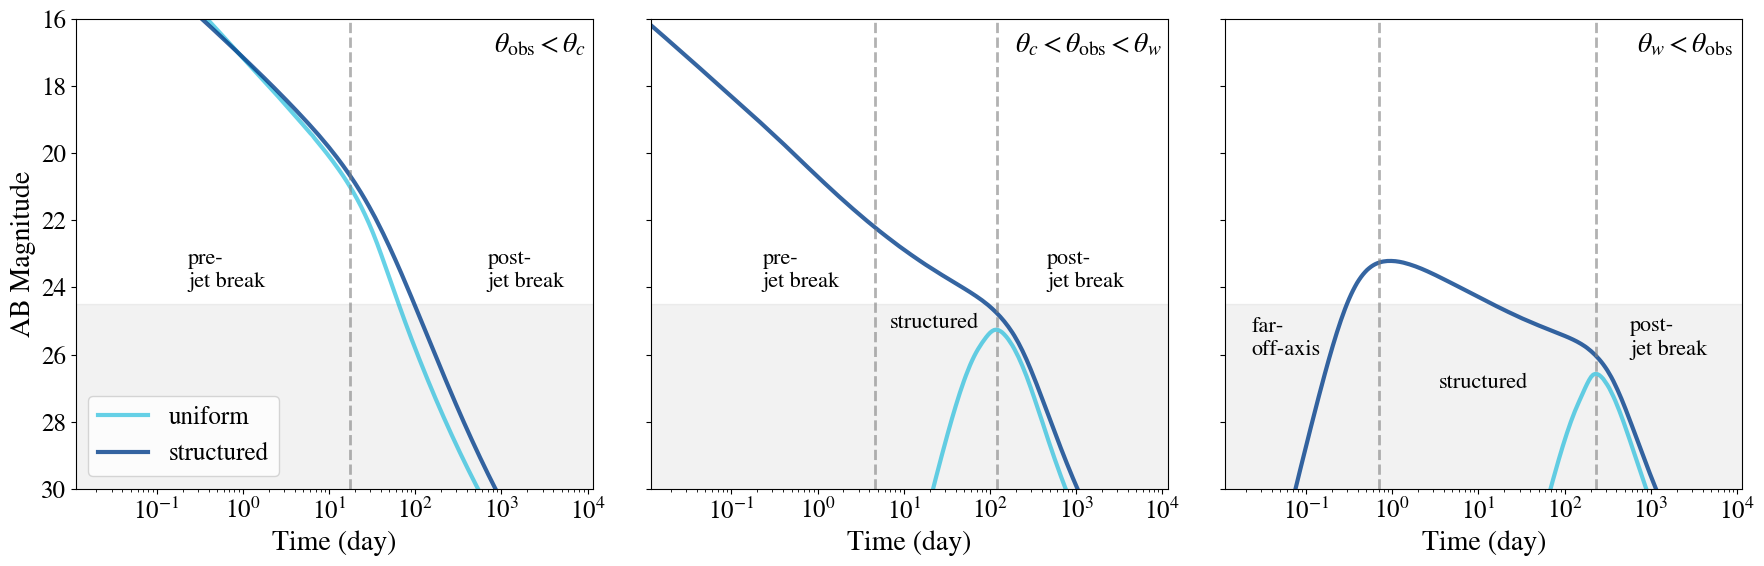

In [22]:
t = np.geomspace(1.0e2, 1.0e9, 300)
nu = 5.0e14

Z = {"jetType": grb.jet.PowerLaw,
     "specType": 0,       # Synchrotron spectrum
     "thetaCore": 0.1,   # Core angle [rad]
     "thetaWing": 0.4,    # Truncation angle [rad]
     "b": 4.0,            # Power-law index
     "E0": 1.0e52,        # erg
     "n0": 0.001,           # cm^{-3}
     "p": 2.2,
     "epsilon_e": 0.1,
     "epsilon_B": 0.01,
     "xi_N": 1.0,
     "d_L": 1.0e28,       # cm
     "z": 0.55
    }

theta_obs_list = [0.08, 0.35, 0.45]  # < theta_c, between, > theta_w

labels = [
    r"$\theta_{\rm obs} < \theta_c$",
    r"$\theta_c < \theta_{\rm obs} < \theta_w$",
    r"$\theta_w < \theta_{\rm obs}$"
]

plt.rcParams.update({'font.size': 18})
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Top-Hat
for i, theta_obs in enumerate(theta_obs_list):
    Z["jetType"] = grb.jet.TopHat
    Z["thetaObs"] = theta_obs

    # Compute flux in Jy, convert to erg/s/cm²/Hz
    Fnu = grb.fluxDensity(t, nu, **Z) * 1.0e-23

    # Convert to AB magnitudes
    mag = -2.5 * np.log10(Fnu) - 48.6

    ax = axes[i]
    ax.plot(t*grb.sec2day, mag, color="#00b4d8", alpha=0.6, lw=3, label="uniform")

# Power-Law
for i, theta_obs in enumerate(theta_obs_list):
    Z["jetType"] = grb.jet.PowerLaw
    Z["thetaObs"] = theta_obs

    # Compute flux in Jy, convert to erg/s/cm²/Hz
    Fnu = grb.fluxDensity(t, nu, **Z) * 1.0e-23

    # Convert to AB magnitudes
    mag = -2.5 * np.log10(Fnu) - 48.6

    ax = axes[i]
    ax.plot(t*grb.sec2day, mag, color="#023e8a", lw=3, alpha=0.8, label="structured")

    # Jet break or transition markers
    if i==0:
        ax.axvline(1.5e6*grb.sec2day, color="gray", ls="--", lw=2, alpha=0.6)
        ax.legend()
    elif i==1:
        ax.axvline(4e5*grb.sec2day, color="gray", ls="--", lw=2, alpha=0.6)
        ax.axvline(1.05e7*grb.sec2day, color="gray", ls="--", lw=2, alpha=0.6)
    else:
        ax.axvline(6e4*grb.sec2day, color="gray", ls="--", lw=2, alpha=0.6)
        ax.axvline(2e7*grb.sec2day, color="gray", ls="--", lw=2, alpha=0.6)
    
    ax.set_xlabel(r"Time (day)", fontsize=20)
    if i == 0:
        ax.set_ylabel(r"AB Magnitude", fontsize=20)

    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.set_xlim(1e3*grb.sec2day, 1e9*grb.sec2day)
    ax.set_ylim(30, 16)
    ax.fill_between([1e-3, 1e5], 24.5, 31., color='k', alpha=0.05)

    # Annotations
    if i == 0:
        ax.text(7e7*grb.sec2day, 17, labels[i], fontsize=20)
        ax.text(2e4*grb.sec2day, 24, "pre-\njet break", fontsize=16)
        ax.text(6e7*grb.sec2day, 24, "post-\njet break", fontsize=16)
    elif i == 1:
        ax.text(1.7e7*grb.sec2day, 17, labels[i], fontsize=20)
        ax.text(2e4*grb.sec2day, 24, "pre-\njet break", fontsize=16)
        ax.text(6e5*grb.sec2day, 25.2, "structured", fontsize=16)
        ax.text(4e7*grb.sec2day, 24, "post-\njet break", fontsize=16)
    else:
        ax.text(6e7*grb.sec2day, 17, labels[i], fontsize=20)
        ax.text(2e3*grb.sec2day, 26, "far-\noff-axis", fontsize=16)
        ax.text(3e5*grb.sec2day, 27, "structured", fontsize=16)
        ax.text(5e7*grb.sec2day, 26, "post-\njet break", fontsize=16)
  

plt.tight_layout()

#plt.savefig('../figures/lc_dependance_angle_structure.pdf', format="pdf", bbox_inches="tight", transparent=True)

### Spectra

(23.0, 21.0)

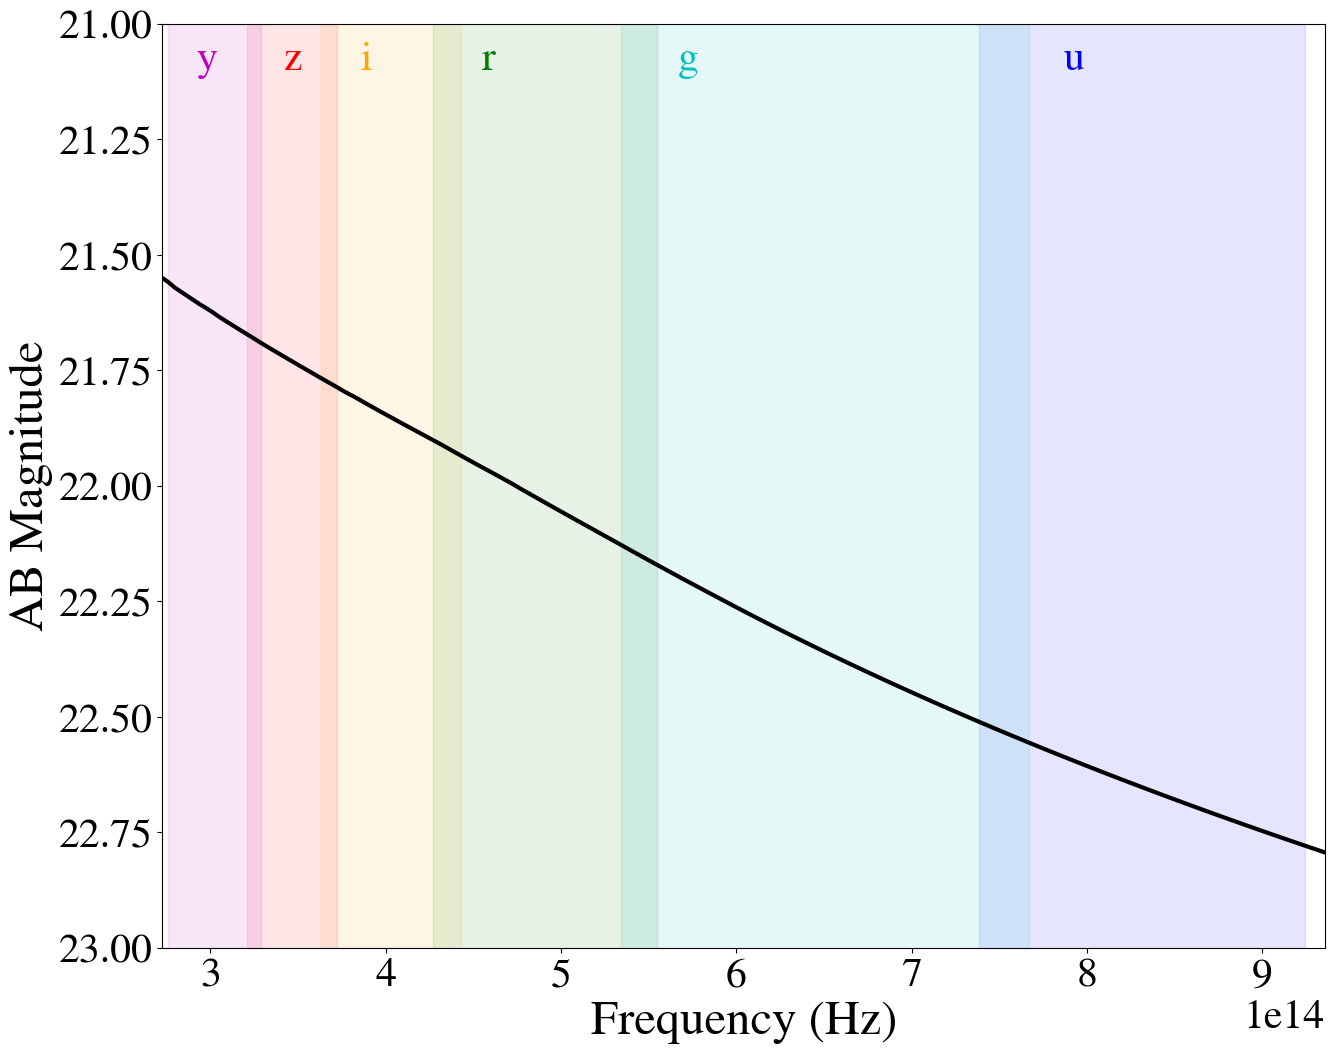

In [23]:
Z = {'jetType':     grb.jet.PowerLaw,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.25,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.2,    # Truncation angle in radians
     'thetaCore':   0.06,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.0e28,  # Luminosity distance in cm
     'z':           0.55}    # Redshift

# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 3.0e7, 300)

# Calculate flux in optical (r-band : wavelength = 600 nm)
# The frequency is the same at each time
nu = np.empty(t.shape)
nu[:] = 5.0e14   

nu_min = 3.0e8/(10999.99e-10)
nu_max = 3.0e8/(3206.34e-10)

u_min = 3206.34
u_max = 4081.51
g_min = 3876.02
g_max = 5665.33
r_min = 5376.31
r_max = 7055.18	
i_min = 6765.95
i_max = 8325.18
z_min = 8035.64
z_max = 9380.16
y_min = 9091.29
y_max = 10999.99

l_filters = [(3206.34, 4081.51), (3876.02, 5665.33), (5376.31, 7055.18), (6765.95, 8325.18), (8035.64, 9380.16), (9091.29, 10999.99)]
filt_colours = ['b', 'c', 'g','orange', 'r', 'm']
filt_labels = ['u', 'g', 'r', 'i', 'z', 'y']

nu = np.geomspace(nu_min, nu_max, num=100)

t = 1.0 * grb.day2sec  # spectrum at 1 day
Fnu = grb.fluxDensity(t, nu, **Z)
mag = -2.5 * np.log10(Fnu*1.0e-26) - 48.6

plt.rcParams.update({'font.size': 30})
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

ax.plot(nu, mag, color='k', lw=3, label='spectrum at 1 day')

ax.set_xlabel('Frequency (Hz)', fontsize=35)
ax.set_ylabel('AB Magnitude', fontsize=35)
ax.invert_yaxis()

for i, l in enumerate(l_filters):
    min_filt = 3.0e8/(l[0]*1e-10)
    max_filt = 3.0e8/(l[1]*1e-10)
    ax.fill_between(nu, 50, color = filt_colours[i], alpha=0.1, where = (nu > max_filt) & (nu < min_filt))
    ax.text(max_filt*1.07, 21.1, filt_labels[i], color = filt_colours[i]) 
#ax.set_xscale('log')
ax.set_xlim(nu_min, nu_max)
ax.set_ylim(23, 21)

#plt.savefig('../figures/orphan_spec_th.png', bbox_inches="tight", transparent=True)

[1.96304065e+09]


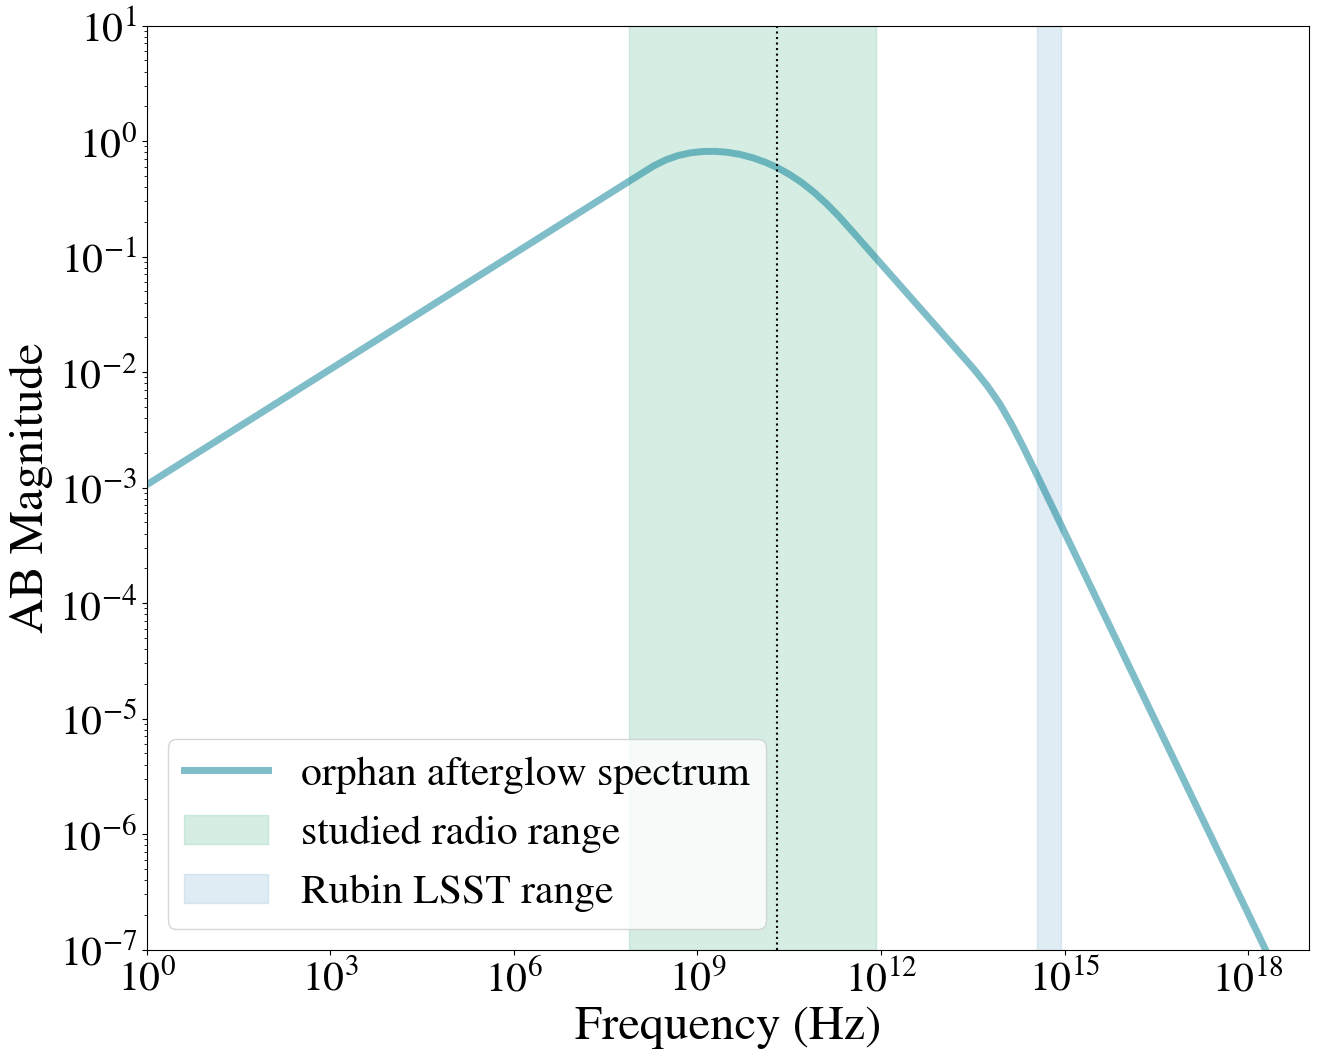

In [24]:
# Space time points geometrically, from 10^3 s to 10^9 s
t = np.geomspace(1.0e3, 3.0e7, 300)

# Calculate flux in optical (r-band : wavelength = 600 nm)
# The frequency is the same at each time
nu = np.empty(t.shape)
nu[:] = 5.0e14   

# Top-Hat: -1, Gaussian: 0, Power-Law: 4)
jettype = [-1, 0, 4]
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']
colors = ['#007c95', '#00b1cb', '#00344b']

nua = 1.0e0   # Low Frequencies in Hz
nub = 1.0e20  # High Frequencies in Hz

nu_min = 0.058e9   # min radio
nu_max = 950e9   # max radio

nu_min_lsst = 3.0e8/(10999.99e-10)
nu_max_lsst = 3.0e8/(3206.34e-10)

t = 0.1 * grb.day2sec  # spectrum at 1 day
nu = np.geomspace(nua, nub, num=100)

Fnu_01 = grb.fluxDensity(t, nu, **Z)
mag_01 = -2.5 * np.log10(Fnu_01*1.0e-26) - 48.6

t = 1.0 * grb.day2sec  # spectrum at 1 day
Fnu_1 = grb.fluxDensity(t, nu, **Z)
mag_1 = -2.5 * np.log10(Fnu_1*1.0e-26) - 48.6

t = 10.0 * grb.day2sec  # spectrum at 1 day
Fnu_10 = grb.fluxDensity(t, nu, **Z)
mag_10 = -2.5 * np.log10(Fnu_10*1.0e-26) - 48.6

print(nu[np.where(Fnu_10==np.max(Fnu_10))])

plt.rcParams.update({'font.size': 30})
fig, ax = plt.subplots(1, 1, figsize=(15, 12))

#ax.plot(nu, mag_01, color=colors[0], alpha=0.5, lw=5)
ax.plot(nu, Fnu_10, color=colors[0], alpha=0.5, lw=5, label='orphan afterglow spectrum')
#ax.plot(nu, mag_10, color=colors[0], alpha=0.5, lw=5)
ax.fill_between(nu, 50, color = '#78c6a3', alpha=0.3, where = (nu > nu_min) & (nu < nu_max), label='studied radio range')
ax.fill_between(nu, 50, color = '#98c1d9', alpha=0.3, where = (nu > nu_min_lsst) & (nu < nu_max_lsst), label='Rubin LSST range')

ax.set_xlabel('Frequency (Hz)', fontsize=35)
ax.set_ylabel('AB Magnitude', fontsize=35)
ax.axvline(2.009233e+10, ls=':', color='k')
#ax.invert_yaxis()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(1, 1e19)
ax.set_ylim(1e-7, 1e1)

ax.legend()

#plt.savefig('../figures/orphan_spec_th_radio.pdf', format="pdf", bbox_inches="tight", transparent=True)

## For how much time can we observe the afterglow ?

In [25]:
def obs_duration(t, mag):
    """Function that compute the number of days for which the afterglow is observable (mag < 24.5)
    """
    
    obs_t = t[np.where(mag < 24.5)[0]]
    
    if obs_t.size == 0:
        return 0
    else:
        return (max(obs_t) - min(obs_t))*grb.sec2day

The afterglow for the Top-Hat jet is not observable.
The afterglow for the Gaussian jet is observable during 15.02 days.
The afterglow for the Power-Law jet is observable during 17.24 days.


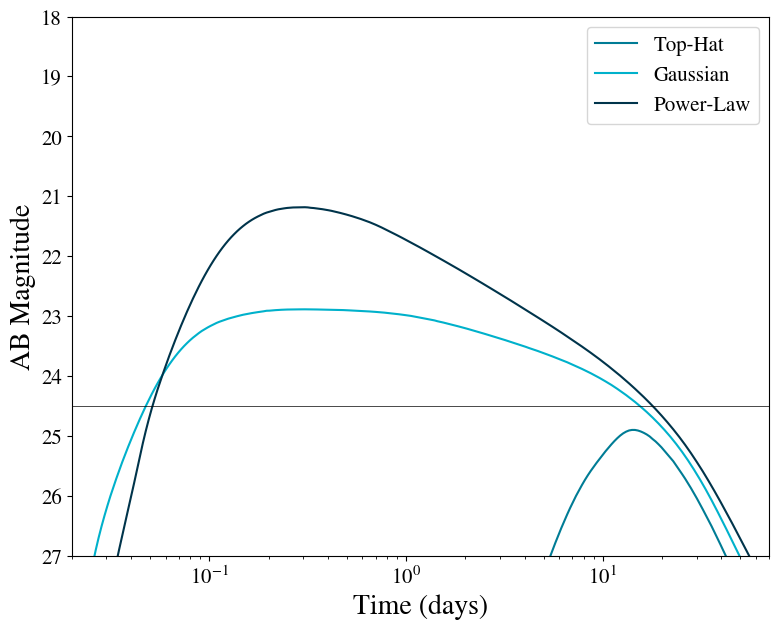

In [26]:
Z = {'jetType':     grb.jet.TopHat,     # Jet Type
     'specType':    0,                  # Emission Spectrum
     'b':           4,       # Power Law index
     'thetaObs':    0.28,     # Viewing angle in radians
     'E0':          1.0e53,  # Isotropic-equivalent energy in erg
     'thetaWing':   0.23,    # Truncation angle in radians
     'thetaCore':   0.08,     # Half-opening angle in radians
     'n0':          1.0,     # Circumburst density in cm^{-3}
     'p':           2.2,     # Electron energy distribution index
     'epsilon_e':   0.1,     # epsilon_e
     'epsilon_B':   0.01,    # epsilon_B
     'xi_N':        1.0,     # Fraction of electrons accelerated
     'd_L':         1.0e28,  # Luminosity distance in cm
     'z':           0.55}    # Redshift

t = np.geomspace(1.0e3, 3.0e7, 300)

nu = np.empty(t.shape)
nu[:] = 5.0e14   

# Top-Hat: -1, Gaussian: 0, Power-Law: 4)
jettype = [-1, 0, 4]
jettype_name = ['Top-Hat', 'Gaussian', 'Power-Law']
colors = ['#007c95', '#00b1cb', '#00344b']


plt.rcParams.update({'font.size': 15})
plt.figure(figsize=(9,7))


for i, j in enumerate(jettype):
    Z['jetType'] = j
    Fnu = grb.fluxDensity(t, nu, **Z)*1.0e-3   # flux in Jansky
    mag = -2.5 * np.log10(Fnu*1.0e-23) - 48.6
    plt.plot(t*grb.sec2day, mag, color=colors[i], label = jettype_name[i])
    
    dt = obs_duration(t, mag)

    if dt > 0:
        print('The afterglow for the %s jet is observable during %.2f days.' %(jettype_name[i],dt))
    else:
        print('The afterglow for the %s jet is not observable.' %jettype_name[i])


plt.xlabel('Time (days)', fontsize=20)
plt.ylabel('AB Magnitude', fontsize=20)
plt.gca().invert_yaxis()
plt.xscale('log')
plt.axhline(y=24.5, color='black', linewidth=0.5)
plt.xlim(0.02, 70)
plt.ylim(27, 18)

plt.legend()